In [1]:
# Se importan librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

In [2]:
dataset = pd.read_csv('/workspaces/financial-data-analytics/data/Coca_cola_prices.csv')
dataset.head(10)

,Date,Price,Open,High,Low,Vol.,Change %
0,11/05/2025,136.07,134.00,136.20,133.82,97.81K,1.86%
1,11/04/2025,133.59,131.90,133.89,131.00,378.42K,2.00%
2,11/03/2025,130.97,130.33,131.49,127.09,368.57K,0.45%
3,10/31/2025,130.38,131.44,131.49,129.30,387.98K,-1.59%
4,10/30/2025,132.49,130.21,138.90,129.28,695.71K,3.53%
5,10/29/2025,127.97,127.00,128.00,126.00,556.72K,-0.12%
6,10/28/2025,128.13,128.45,129.49,126.00,586.22K,-0.03%
7,10/27/2025,128.17,127.71,129.35,127.62,346.91K,0.40%
8,10/24/2025,127.66,127.78,128.05,126.75,323.20K,-0.04%
9,10/23/2025,127.71,129.22,129.44,127.06,346.64K,-1.17%


In [3]:
# Para los cálculos de correlación y covarianza se crea una columna adicional con nombre Returns para que almacene el % de variación en formato float.

dataset['Returns'] = dataset['Change %'].str.replace('%', '').astype(float) / 100
dataset.head(5)

,Date,Price,Open,High,Low,Vol.,Change %,Returns
0,11/05/2025,136.07,134.00,136.20,133.82,97.81K,1.86%,0.0186
1,11/04/2025,133.59,131.90,133.89,131.00,378.42K,2.00%,0.0200
2,11/03/2025,130.97,130.33,131.49,127.09,368.57K,0.45%,0.0045
3,10/31/2025,130.38,131.44,131.49,129.30,387.98K,-1.59%,-0.0159
4,10/30/2025,132.49,130.21,138.90,129.28,695.71K,3.53%,0.0353


In [4]:
# Cálculo descriptivo
promedio = float(np.average(dataset['Price']))
varianza = float(np.var(dataset['Price'], ddof=1)) #varianza muestral
desviacion_estandar = float(np.std(dataset['Price'], ddof=1)) #desviación estándar muestral
asimetria = float(skew(dataset['Price']))
curtosis = float(kurtosis(dataset['Price'])) #Fisher kurtosis (excess kurtosis): normal = 0
covarianza = np.cov(dataset['Price'],dataset['Returns'])[0,1]
correlacion = np.corrcoef(dataset['Price'],dataset['Returns'])[0,1]

print(f'Análisis descriptivo del precio de la acción de coca-cola\nPromedio: {promedio}\nVarianza: {varianza}\nDesviación estándar: {desviacion_estandar}\nAsimetría: {asimetria}\nCurtosis: {curtosis}\ncorrelacion: {correlacion}\ncovarianza: {covarianza}'
      )

Análisis descriptivo del precio de la acción de coca-cola
Promedio: 124.1437132352941
Varianza: 92.20842416838506
Desviación estándar: 9.602521760890994
Asimetría: 0.13418794655495694
Curtosis: -1.0509623745899446
correlacion: 0.14003799337089026
covarianza: 0.026690970154113307


# Desarrollo de la tarea 4
### 1. Fuente de datos de dos acciones de la bolsa de Estados Unidos y hacer el análisis estadístico descriptivo
### 2. Intepretar los resultados
### 3. Histograma de precios 
### 4. Responder a qué función se parece: normal, uniforme, log normal

In [5]:
# Se instala la librería de python para acceder a datos de yahoo finance
!pip install yfinance -q

In [6]:
import yfinance as yf

### 1. Fuente de datos

In [7]:
# Descargar datos históricos de la acción de Google en el periodo de un año e intervalo diario.
def consulta_accion(nombre, periodo, intervalo):
    ticker = yf.Ticker(nombre) 
    historical = ticker.history(period=periodo, interval=intervalo) 
    return historical

In [8]:
# Consulta de datos para la acción de Google
nombre = "GOOG" # Google Alphabet 
periodo = "1y"
intervalo = "1d"

google = consulta_accion(nombre, periodo, intervalo)

# Visualización de los datos
google_df = pd.DataFrame(google)
google_df.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2024-11-25 00:00:00-05:00,167.257969,169.717207,166.670528,168.691681,21395700,0.0,0.0
2024-11-26 00:00:00-05:00,168.751430,170.747682,168.691679,169.876495,14937500,0.0,0.0
2024-11-27 00:00:00-05:00,169.936233,170.394235,168.930640,170.075638,12433400,0.0,0.0
2024-11-29 00:00:00-05:00,169.318936,170.125404,168.014647,169.747070,9250700,0.0,0.0
2024-12-02 00:00:00-05:00,169.577814,172.843520,169.528029,172.226212,16593400,0.0,0.0
2024-12-03 00:00:00-05:00,172.365607,173.560390,171.758265,172.266052,15721500,0.0,0.0
2024-12-04 00:00:00-05:00,172.027103,175.661192,171.997235,175.322678,18239800,0.0,0.0
2024-12-05 00:00:00-05:00,176.547324,176.935624,173.251735,173.550430,16145500,0.0,0.0
2024-12-06 00:00:00-05:00,173.122305,176.068410,172.793741,175.720932,13319500,0.0,0.0


In [9]:
# Cálculo de los retornos
google_df['Returns'] = (google_df['Close']-google_df['Close'].shift(-1))/google_df['Close'].shift(-1)
google_df.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Returns
Date,,,,,,,,
2024-11-25 00:00:00-05:00,167.257969,169.717207,166.670528,168.691681,21395700,0.0,0.0,-0.006975
2024-11-26 00:00:00-05:00,168.751430,170.747682,168.691679,169.876495,14937500,0.0,0.0,-0.001171
2024-11-27 00:00:00-05:00,169.936233,170.394235,168.930640,170.075638,12433400,0.0,0.0,0.001936
2024-11-29 00:00:00-05:00,169.318936,170.125404,168.014647,169.747070,9250700,0.0,0.0,-0.014395
2024-12-02 00:00:00-05:00,169.577814,172.843520,169.528029,172.226212,16593400,0.0,0.0,-0.000231
2024-12-03 00:00:00-05:00,172.365607,173.560390,171.758265,172.266052,15721500,0.0,0.0,-0.017434
2024-12-04 00:00:00-05:00,172.027103,175.661192,171.997235,175.322678,18239800,0.0,0.0,0.010212
2024-12-05 00:00:00-05:00,176.547324,176.935624,173.251735,173.550430,16145500,0.0,0.0,-0.012352
2024-12-06 00:00:00-05:00,173.122305,176.068410,172.793741,175.720932,13319500,0.0,0.0,-0.004574


In [18]:
# Definición de la función para cálculo de los estadísticos

def descriptive_statistics(price, returns, accion):
    promedio = float(np.average(price))
    varianza = float(np.var(price, ddof=1)) #varianza muestral
    desviacion_estandar = float(np.std(price, ddof=1)) #desviación estándar muestral
    asimetria = float(skew(price))
    curtosis = float(kurtosis(price, fisher=False)) #Fisher kurtosis (excess kurtosis): normal = 0
    covarianza = np.cov(price,returns)[0,0]
    correlacion = np.corrcoef(price,returns)[0,0]
    print(f'Análisis descriptivo del precio de la acción de {accion}\nPromedio: {promedio}\nVarianza: {varianza}\nDesviación estándar: {desviacion_estandar}\nAsimetría: {asimetria}\nCurtosis: {curtosis}\ncorrelacion: {correlacion}\ncovarianza: {covarianza}'
      )

In [19]:
# Cálculo de los estadísticos
accion = 'Google'
google_price = google_df['Close']
google_returns = google_df['Returns']

descriptive_statistics(google_price,google_returns,accion)

Análisis descriptivo del precio de la acción de Google
Promedio: 198.87042010498047
Varianza: 1462.7152329323208
Desviación estándar: 38.24546029180876
Asimetría: 1.0411768948314062
Curtosis: 3.107403129241477
correlacion: 1.0
covarianza: 1462.7152329323208


In [20]:
# Consulta de datos para la acción de Bitcoin
nombre = "BTC-USD" # Bitcoin USD
periodo = "1y"
intervalo = "1d"

bitcoin = consulta_accion(nombre, periodo, intervalo)

# Visualización de los datos
bitcoin_df = pd.DataFrame(bitcoin)
bitcoin_df.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2024-11-25 00:00:00+00:00,98033.445312,98935.031250,92642.914062,93102.296875,80909462490,0.0,0.0
2024-11-26 00:00:00+00:00,93087.281250,94991.750000,90770.812500,91985.320312,91656519855,0.0,0.0
2024-11-27 00:00:00+00:00,91978.140625,97361.179688,91778.664062,95962.531250,71133452438,0.0,0.0
2024-11-28 00:00:00+00:00,95954.945312,96650.203125,94677.351562,95652.468750,52260008261,0.0,0.0
2024-11-29 00:00:00+00:00,95653.953125,98693.171875,95407.882812,97461.523438,54968682476,0.0,0.0
2024-11-30 00:00:00+00:00,97468.812500,97499.343750,96144.218750,96449.054688,31634227866,0.0,0.0
2024-12-01 00:00:00+00:00,96461.335938,97888.125000,95770.187500,97279.789062,36590695296,0.0,0.0
2024-12-02 00:00:00+00:00,97276.007812,98152.601562,94482.867188,95865.304688,72680784305,0.0,0.0
2024-12-03 00:00:00+00:00,95854.593750,96297.203125,93629.562500,96002.164062,67067810961,0.0,0.0


In [21]:
# Cálculo de los retornos
bitcoin_df['Returns'] = (bitcoin_df['Close']-bitcoin_df['Close'].shift(-1))/bitcoin_df['Close'].shift(-1)
bitcoin_df.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Returns
Date,,,,,,,,
2024-11-25 00:00:00+00:00,98033.445312,98935.031250,92642.914062,93102.296875,80909462490,0.0,0.0,0.012143
2024-11-26 00:00:00+00:00,93087.281250,94991.750000,90770.812500,91985.320312,91656519855,0.0,0.0,-0.041445
2024-11-27 00:00:00+00:00,91978.140625,97361.179688,91778.664062,95962.531250,71133452438,0.0,0.0,0.003242
2024-11-28 00:00:00+00:00,95954.945312,96650.203125,94677.351562,95652.468750,52260008261,0.0,0.0,-0.018562
2024-11-29 00:00:00+00:00,95653.953125,98693.171875,95407.882812,97461.523438,54968682476,0.0,0.0,0.010497
2024-11-30 00:00:00+00:00,97468.812500,97499.343750,96144.218750,96449.054688,31634227866,0.0,0.0,-0.008540
2024-12-01 00:00:00+00:00,96461.335938,97888.125000,95770.187500,97279.789062,36590695296,0.0,0.0,0.014755
2024-12-02 00:00:00+00:00,97276.007812,98152.601562,94482.867188,95865.304688,72680784305,0.0,0.0,-0.001426
2024-12-03 00:00:00+00:00,95854.593750,96297.203125,93629.562500,96002.164062,67067810961,0.0,0.0,-0.028009


In [22]:
# Cálculo de los estadísticos
accion = 'Bitcoin'
bitcoin_price = bitcoin_df['Close']
bitcoin_returns = bitcoin_df['Returns']

descriptive_statistics(bitcoin_price,bitcoin_returns,accion)

Análisis descriptivo del precio de la acción de Bitcoin
Promedio: 102512.0906464041
Varianza: 123836416.35116464
Desviación estándar: 11128.18117893327
Asimetría: -0.24379036808151333
Curtosis: 2.1923521745816377
correlacion: 1.0
covarianza: 123836416.35116465


Text(0.5, 1.0, 'Distribución de precios de la acción de Google')

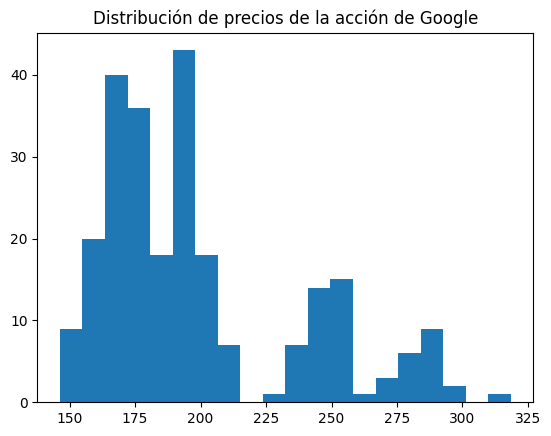

In [23]:
plt.hist(google_price, bins=20)
plt.title('Distribución de precios de la acción de Google')

Text(0.5, 1.0, 'Distribución de precios de la acción de Bitcoin')

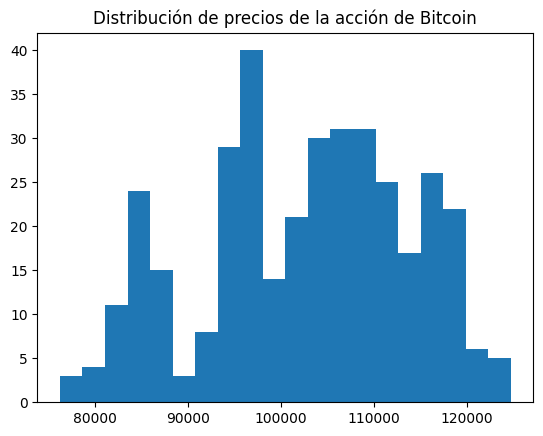

In [24]:
plt.hist(bitcoin_price, bins=20)
plt.title('Distribución de precios de la acción de Bitcoin')

## 2. Interpretación de resultados

### Análisis descriptivo del precio de la acción de Google
- Promedio: 198.87042010498047
- Varianza: 1462.7152329323208
- Desviación estándar: 38.24546029180876
- Asimetría: 1.0411768948314062
- Curtosis: 3.107403129241477
- Correlacion: 1.0
- Covarianza: 1462.7152329323208

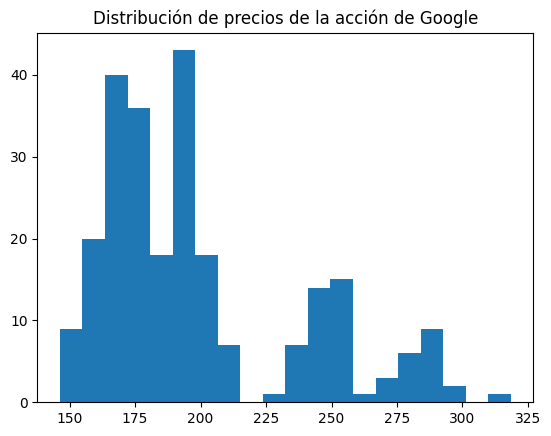

La acción de Google tiene una alta frecuencia de precio al rededor de 198 USD según el gráfico del histograma, este valor se ve reflejado en el promedio. Su distribución es de tipo log-normal, con valores muy concentrados cerca al promedio, reflejado por el valor de la curtosis cercana a 3. La asimetría es positiva, lo que quiere decir que hay una mayor concentración hacia los precios más bajos, con cola a la derecha. Se puede inferir que el comportamiento de la acción durante el año fue estable al rededor de 150 - 200 USD

### Análisis descriptivo del precio de la acción de Bitcoin
- Promedio: 102512.0906464041
- Varianza: 123836416.35116464
- Desviación estándar: 11128.18117893327
- Asimetría: -0.24379036808151333
- Curtosis: 2.1923521745816377
- Correlacion: 1.0
- Covarianza: 123836416.35116465

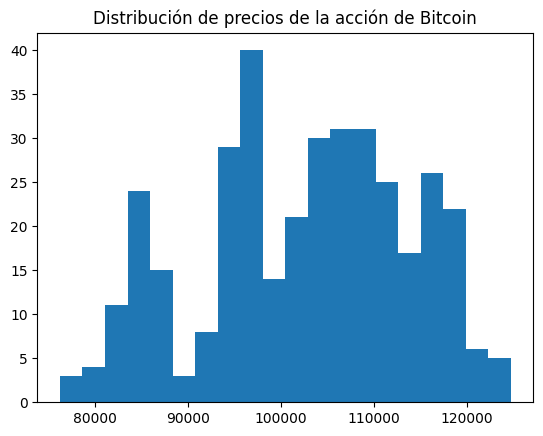

La acción de Bitcoin tiene una alta frecuencia de precio al rededor de 102512 USD según el gráfico del histograma, este valor se ve reflejado en el promedio. Su distribución es de tipo multimodal, sin una cola clara, reflejado por el valor de la curtosis menor a 3 y de tipo platicúrtica. La asimetría es negativa pero cercana a cero, lo que quiere decir que la mayor parte de los datos está hacia la derecha del promedio. Se puede inferir que el comportamiento de la acción durante el año tuvo varios picos y no está fuertemente sesgada hacia un lado.
